# Seq2Seq Translation


In [1]:
import os, re, math, random, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from collections import Counter
from torch.utils.data import Dataset, DataLoader, Sampler
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence

try:
    from tqdm.auto import tqdm
except ImportError:
    tqdm = lambda x, **k: x

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
use_amp = device.type == "cuda"
print("device:", device)

MAX_LEN      = 30
MIN_FREQ     = 5
MAX_VOCAB    = 30000
BATCH_SIZE   = 128
EPOCHS       = 8
LR           = 1e-3
CLIP         = 1.0
EMB_DIM      = 256
HID_DIM      = 512
N_LAYERS     = 2
DROPOUT      = 0.3
TRAIN_SUBSET = None    
VAL_SUBSET   = 5000
NUM_WORKERS  = 0

BASELINE_CKPT    = "best_model.pt"        # Exp 1 checkpoint
ATTN_CKPT        = "best_attn_model.pt"
RETRAIN_BASELINE = False   # False: load the Exp 1 checkpoint if it exists (otherwise train it here)
RETRAIN_ATTN     = True    # False: load best_attn_model.pt from an earlier run

train = pd.read_csv("en_fr_train.csv").dropna().astype(str)
val   = pd.read_csv("en_fr_val.csv").dropna().astype(str)
test  = pd.read_csv("en_fr_test.csv").dropna().astype(str)
print(train.shape, val.shape, test.shape)

c:\Users\shrey\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: cuda
(232825, 2) (890, 2) (8597, 2)


### Data
Punctuation tokenizer, pairs longer than `MAX_LEN` filtered out, vocab capped at 30k words with `min_freq=5`.

In [2]:
def tokenize(s):
    return re.findall(r"\w+|[^\w\s]", str(s).lower())

for df in (train, val, test):
    df["en_tok"] = df["en"].map(tokenize)
    df["fr_tok"] = df["fr"].map(tokenize)

def length_filter(df, max_len=MAX_LEN):
    el = df["en_tok"].str.len()
    fl = df["fr_tok"].str.len()
    return df[(el >= 1) & (el <= max_len) & (fl >= 1) & (fl <= max_len)].reset_index(drop=True)

train_f = length_filter(train)
val_f   = length_filter(val)
print(f"train kept {len(train_f)}/{len(train)} | val kept {len(val_f)}/{len(val)}")

PAD, SOS, EOS, UNK = 0, 1, 2, 3
SPECIAL_TOKENS = ["<PAD>", "<SOS>", "<EOS>", "<UNK>"]

def build_vocab(token_lists, min_freq=MIN_FREQ, max_size=MAX_VOCAB):
    counter = Counter()
    for toks in token_lists:
        counter.update(toks)
    vocab = {t: i for i, t in enumerate(SPECIAL_TOKENS)}
    for w, c in counter.most_common(max_size):
        if c < min_freq:
            break
        vocab[w] = len(vocab)
    return vocab

if os.path.exists("vocab.pt"):
    v = torch.load("vocab.pt")
    en_vocab, fr_vocab = v["en_vocab"], v["fr_vocab"]
    print("loaded vocab.pt (same vocab as Exp 1)")
else:
    en_vocab = build_vocab(train_f["en_tok"])
    fr_vocab = build_vocab(train_f["fr_tok"])
    torch.save({"en_vocab": en_vocab, "fr_vocab": fr_vocab}, "vocab.pt")

en_id_to_word = {i: w for w, i in en_vocab.items()}
fr_id_to_word = {i: w for w, i in fr_vocab.items()}
print("EN vocab:", len(en_vocab), "| FR vocab:", len(fr_vocab))

def encode_ids(tokens, vocab, max_len=MAX_LEN):
    return [SOS] + [vocab.get(t, UNK) for t in tokens[:max_len]] + [EOS]

train kept 173533/232825 | val kept 623/890
EN vocab: 14609 | FR vocab: 17730


In [3]:
class TranslationDataset(Dataset):
    def __init__(self, en_toks, fr_toks):
        self.en = [encode_ids(t, en_vocab) for t in en_toks]
        self.fr = [encode_ids(t, fr_vocab) for t in fr_toks]
        self.lengths = np.array([max(len(a), len(b)) for a, b in zip(self.en, self.fr)])

    def __len__(self):
        return len(self.en)

    def __getitem__(self, i):
        return self.en[i], self.fr[i]


class BucketBatchSampler(Sampler):
    # similar-length sentences share a batch -> very little padding
    def __init__(self, lengths, batch_size, shuffle=True, chunk_mult=50):
        self.lengths = np.asarray(lengths)
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.chunk = batch_size * chunk_mult

    def __iter__(self):
        idx = np.arange(len(self.lengths))
        if self.shuffle:
            np.random.shuffle(idx)
        batches = []
        for i in range(0, len(idx), self.chunk):
            c = idx[i:i + self.chunk]
            c = c[np.argsort(self.lengths[c], kind="stable")]
            batches += [c[j:j + self.batch_size].tolist() for j in range(0, len(c), self.batch_size)]
        if self.shuffle:
            random.shuffle(batches)
        return iter(batches)

    def __len__(self):
        return math.ceil(len(self.lengths) / self.batch_size)


def collate(batch):
    en = pad_sequence([torch.tensor(b[0]) for b in batch], padding_value=PAD)    # (seq_len, batch)
    fr = pad_sequence([torch.tensor(b[1]) for b in batch], padding_value=PAD)
    return en, fr


train_df = train_f.sample(TRAIN_SUBSET, random_state=SEED).reset_index(drop=True) if TRAIN_SUBSET else train_f
val_df   = val_f.sample(min(VAL_SUBSET, len(val_f)), random_state=SEED).reset_index(drop=True) if VAL_SUBSET else val_f

train_dataset = TranslationDataset(train_df["en_tok"], train_df["fr_tok"])
val_dataset   = TranslationDataset(val_df["en_tok"], val_df["fr_tok"])

train_loader = DataLoader(train_dataset,
    batch_sampler=BucketBatchSampler(train_dataset.lengths, BATCH_SIZE, shuffle=True),
    collate_fn=collate, num_workers=NUM_WORKERS, pin_memory=use_amp)
val_loader = DataLoader(val_dataset,
    batch_sampler=BucketBatchSampler(val_dataset.lengths, BATCH_SIZE * 2, shuffle=False),
    collate_fn=collate, num_workers=NUM_WORKERS, pin_memory=use_amp)

en_batch, fr_batch = next(iter(train_loader))
print(en_batch.shape, fr_batch.shape, "| steps/epoch:", len(train_loader))

torch.Size([15, 128]) torch.Size([15, 128]) | steps/epoch: 1356


### Model 1: baseline
The decoder only sees the encoder's final states (one fixed-size context vector).

In [4]:
class BaselineEncoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, hid_dim, n_layers, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD)
        self.dropout = nn.Dropout(dropout)
        self.lstm = nn.LSTM(emb_dim, hid_dim, num_layers=n_layers,
                            dropout=dropout if n_layers > 1 else 0.0)

    def forward(self, src):
        lengths = (src != PAD).sum(0).cpu()
        emb = self.dropout(self.embedding(src))
        packed = pack_padded_sequence(emb, lengths, enforce_sorted=False)
        _, (hidden, cell) = self.lstm(packed)
        return hidden, cell


class BaselineDecoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, hid_dim, n_layers, dropout):
        super().__init__()
        self.output_dim = vocab_size
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD)
        self.dropout = nn.Dropout(dropout)
        self.lstm = nn.LSTM(emb_dim, hid_dim, num_layers=n_layers,
                            dropout=dropout if n_layers > 1 else 0.0)
        self.fc_out = nn.Linear(hid_dim, vocab_size)

    def forward(self, token, hidden, cell):
        emb = self.dropout(self.embedding(token.unsqueeze(0)))
        output, (hidden, cell) = self.lstm(emb, (hidden, cell))
        return self.fc_out(output.squeeze(0)), hidden, cell


class BaselineSeq2Seq(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward_tf(self, src, trg):
        hidden, cell = self.encoder(src)
        emb = self.decoder.dropout(self.decoder.embedding(trg[:-1]))
        out, _ = self.decoder.lstm(emb, (hidden, cell))
        return self.decoder.fc_out(out)                            # (T-1, B, V)

    @torch.no_grad()
    def greedy_decode(self, src, max_len=80):
        hidden, cell = self.encoder(src)
        B = src.shape[1]
        token = torch.full((B,), SOS, dtype=torch.long, device=src.device)
        finished = torch.zeros(B, dtype=torch.bool, device=src.device)
        outs = []
        for _ in range(max_len):
            logits, hidden, cell = self.decoder(token, hidden, cell)
            token = logits.argmax(1)
            outs.append(token)
            finished |= token == EOS
            if finished.all():
                break
        return torch.stack(outs, 1).cpu()


baseline = BaselineSeq2Seq(
    BaselineEncoder(len(en_vocab), EMB_DIM, HID_DIM, N_LAYERS, DROPOUT),
    BaselineDecoder(len(fr_vocab), EMB_DIM, HID_DIM, N_LAYERS, DROPOUT),
).to(device)
print(f"baseline parameters: {sum(p.numel() for p in baseline.parameters())/1e6:.1f}M")

baseline parameters: 24.7M


### Model 2: Luong attention
The encoder now returns all its hidden states. After the decoder LSTM produces its state at each step, attention scores it against
every encoder state $$\text{score} = h_{\text{dec}}^T W h_{\text{enc}}$$, padding masked, builds a context vector as the weighted sum, and combines both to context vector
$$
c_t = \sum_s \alpha_{t,s} h_s
$$

Greedy Decoding : Way of generating sequence one token at a time where each step we choose highest probable token

In [5]:
class AttnEncoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, hid_dim, n_layers, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD)
        self.dropout = nn.Dropout(dropout)
        self.lstm = nn.LSTM(emb_dim, hid_dim, num_layers=n_layers,
                            dropout=dropout if n_layers > 1 else 0.0)

    def forward(self, src):                  
        mask = (src != PAD).transpose(0, 1)   #words which are not padded  
        lengths = (src != PAD).sum(0).cpu()   #length of unpadded word
        emb = self.dropout(self.embedding(src))
        packed = pack_padded_sequence(emb, lengths, enforce_sorted=False)  #remove padding for computation
        packed_out, (hidden, cell) = self.lstm(packed)
        enc_out, _ = pad_packed_sequence(packed_out, total_length=src.shape[0])   # (S, B, H)
        return enc_out.transpose(0, 1), hidden, cell, mask    # enc_out: (B, S, H)


class LuongAttention(nn.Module):
    def __init__(self, hid_dim):
        super().__init__()
        self.W = nn.Linear(hid_dim, hid_dim, bias=False)

    def forward(self, dec_out, enc_out, mask):
        # dec_out (B, T, H), enc_out (B, S, H), mask (B, S)      T->Target sequence length S->Source sequence length
        scores = torch.bmm(dec_out, self.W(enc_out).transpose(1, 2))   # (B, T, S) 
        scores = scores.masked_fill(~mask.unsqueeze(1), -1e4)    # ignore padding
        attn = torch.softmax(scores, dim=-1)  #normalizing the weights
        context = torch.bmm(attn, enc_out)  # context vector using batch matrix multiplication
        return context, attn


class AttnDecoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, hid_dim, n_layers, dropout):
        super().__init__()
        self.output_dim = vocab_size
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD)
        self.dropout = nn.Dropout(dropout)
        self.lstm = nn.LSTM(emb_dim, hid_dim, num_layers=n_layers,
                            dropout=dropout if n_layers > 1 else 0.0)
        self.attention = LuongAttention(hid_dim)
        self.concat = nn.Linear(2 * hid_dim, hid_dim) #decoder hidden state + context vector
        self.fc_out = nn.Linear(hid_dim, vocab_size)

    def combine(self, dec_out, enc_out, mask):
        # dec_out (B, T, H) -> logits (B, T, V), attention weights (B, T, S)
        context, attn = self.attention(dec_out, enc_out, mask)
        combined = torch.tanh(self.concat(torch.cat([dec_out, context], dim=-1)))
        return self.fc_out(self.dropout(combined)), attn

    def step(self, token, hidden, cell, enc_out, mask):
        # one decoding step: token (B,)
        emb = self.dropout(self.embedding(token.unsqueeze(0)))
        out, (hidden, cell) = self.lstm(emb, (hidden, cell))
        logits, attn = self.combine(out.transpose(0, 1), enc_out, mask)
        return logits.squeeze(1), hidden, cell, attn.squeeze(1)


class Seq2SeqAttn(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward_tf(self, src, trg):
        # teacher forcing, decoder LSTM in one call, output (T-1, B, V) aligned with trg[1:]
        enc_out, hidden, cell, mask = self.encoder(src)
        emb = self.decoder.dropout(self.decoder.embedding(trg[:-1]))
        out, _ = self.decoder.lstm(emb, (hidden, cell))
        logits, _ = self.decoder.combine(out.transpose(0, 1), enc_out, mask)
        return logits.transpose(0, 1)

    @torch.no_grad()
    def greedy_decode(self, src, max_len=80, return_attn=False):
        enc_out, hidden, cell, mask = self.encoder(src)
        B = src.shape[1]
        token = torch.full((B,), SOS, dtype=torch.long, device=src.device)
        finished = torch.zeros(B, dtype=torch.bool, device=src.device)
        outs, attns = [], []
        for _ in range(max_len):
            logits, hidden, cell, attn = self.decoder.step(token, hidden, cell, enc_out, mask)
            token = logits.argmax(1)
            outs.append(token)
            attns.append(attn)
            finished |= token == EOS
            if finished.all():
                break
        out = torch.stack(outs, 1).cpu()
        if return_attn:
            return out, torch.stack(attns, 1).float().cpu()       # (B, T, S)
        return out

    @torch.no_grad()
    def sample_decode(self, src, max_len=80, top_k=10, temperature=0.8):
        # random sampling from the top-k most likely words at each step
        enc_out, hidden, cell, mask = self.encoder(src)
        B = src.shape[1]
        token = torch.full((B,), SOS, dtype=torch.long, device=src.device)
        finished = torch.zeros(B, dtype=torch.bool, device=src.device)
        outs = []
        for _ in range(max_len):
            logits, hidden, cell, _ = self.decoder.step(token, hidden, cell, enc_out, mask)
            logits = logits.float() / temperature
            logits[:, PAD] = float("-inf")
            logits[:, SOS] = float("-inf")
            if top_k:
                kth = logits.topk(top_k, dim=-1).values[:, -1:]
                logits = logits.masked_fill(logits < kth, float("-inf"))
            token = torch.multinomial(torch.softmax(logits, dim=-1), 1).squeeze(1)
            outs.append(token)
            finished |= token == EOS
            if finished.all():
                break
        return torch.stack(outs, 1).cpu()


attn_model = Seq2SeqAttn(
    AttnEncoder(len(en_vocab), EMB_DIM, HID_DIM, N_LAYERS, DROPOUT),
    AttnDecoder(len(fr_vocab), EMB_DIM, HID_DIM, N_LAYERS, DROPOUT),
).to(device)
print(f"attention parameters: {sum(p.numel() for p in attn_model.parameters())/1e6:.1f}M")

attention parameters: 25.5M


### Training
One shared training routine for both models (same optimiser, epochs, clipping, mixed precision), saving the best-validation checkpoint.
The baseline is loaded from the Exp 1 checkpoint if available, otherwise it is trained here.

In [6]:
criterion = nn.CrossEntropyLoss(ignore_index=PAD)


def run_epoch(m, loader, train_mode, optimizer=None, scaler=None):
    m.train(train_mode)
    total, n = 0.0, 0
    for src, trg in tqdm(loader, leave=False):
        src = src.to(device, non_blocking=True)
        trg = trg.to(device, non_blocking=True)
        with torch.set_grad_enabled(train_mode):
            with torch.autocast(device_type=device.type, enabled=use_amp):
                out = m.forward_tf(src, trg)                          # (T-1, B, V)
                loss = criterion(out.reshape(-1, out.shape[-1]), trg[1:].reshape(-1))
            if train_mode:
                optimizer.zero_grad(set_to_none=True)
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(m.parameters(), CLIP)
                scaler.step(optimizer)
                scaler.update()
        total += loss.item()
        n += 1
    return total / n


def fit(m, ckpt, epochs, name):
    optimizer = torch.optim.Adam(m.parameters(), lr=LR)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=1)
    scaler = torch.amp.GradScaler("cuda", enabled=use_amp)
    tr_hist, va_hist, best = [], [], float("inf")
    for epoch in range(epochs):
        t0 = time.time()
        tr = run_epoch(m, train_loader, True, optimizer, scaler)
        va = run_epoch(m, val_loader, False)
        scheduler.step(va)
        tr_hist.append(tr); va_hist.append(va)
        if va < best:
            best = va
            torch.save(m.state_dict(), ckpt)
        print(f"[{name}] epoch {epoch+1}/{epochs} | {time.time()-t0:.0f}s | "
              f"train {tr:.3f} (ppl {math.exp(tr):.1f}) | val {va:.3f} (ppl {math.exp(va):.1f})"
              f"{'  <- best' if va == best else ''}")
    m.load_state_dict(torch.load(ckpt, map_location=device))
    m.eval()
    return tr_hist, va_hist

In [7]:
base_hist = ([], [])
loaded = False
if os.path.exists(BASELINE_CKPT) and not RETRAIN_BASELINE:
    try:
        baseline.load_state_dict(torch.load(BASELINE_CKPT, map_location=device))
        baseline.eval()
        loaded = True
        print("loaded baseline from", BASELINE_CKPT)
    except RuntimeError as e:
        print("baseline checkpoint does not match this config, retraining it here\n", str(e)[:200])
if not loaded:
    base_hist = fit(baseline, BASELINE_CKPT, EPOCHS, "baseline")

[baseline] epoch 1/8 | 57s | train 4.288 (ppl 72.8) | val 3.683 (ppl 39.8)  <- best


[baseline] epoch 2/8 | 56s | train 3.269 (ppl 26.3) | val 3.325 (ppl 27.8)  <- best


[baseline] epoch 3/8 | 56s | train 2.929 (ppl 18.7) | val 3.138 (ppl 23.1)  <- best


[baseline] epoch 4/8 | 56s | train 2.699 (ppl 14.9) | val 3.015 (ppl 20.4)  <- best


[baseline] epoch 5/8 | 55s | train 2.525 (ppl 12.5) | val 2.940 (ppl 18.9)  <- best


[baseline] epoch 6/8 | 55s | train 2.381 (ppl 10.8) | val 2.879 (ppl 17.8)  <- best


[baseline] epoch 7/8 | 56s | train 2.260 (ppl 9.6) | val 2.835 (ppl 17.0)  <- best


[baseline] epoch 8/8 | 59s | train 2.157 (ppl 8.6) | val 2.802 (ppl 16.5)  <- best


In [8]:
attn_hist = ([], [])
if RETRAIN_ATTN or not os.path.exists(ATTN_CKPT):
    attn_hist = fit(attn_model, ATTN_CKPT, EPOCHS, "attention")
else:
    attn_model.load_state_dict(torch.load(ATTN_CKPT, map_location=device))
    attn_model.eval()
    print("loaded attention model from", ATTN_CKPT)

[attention] epoch 1/8 | 63s | train 4.177 (ppl 65.2) | val 3.583 (ppl 36.0)  <- best


[attention] epoch 2/8 | 62s | train 3.163 (ppl 23.7) | val 2.971 (ppl 19.5)  <- best


[attention] epoch 3/8 | 62s | train 2.539 (ppl 12.7) | val 2.529 (ppl 12.5)  <- best


[attention] epoch 4/8 | 62s | train 2.190 (ppl 8.9) | val 2.330 (ppl 10.3)  <- best


[attention] epoch 5/8 | 62s | train 1.985 (ppl 7.3) | val 2.228 (ppl 9.3)  <- best


[attention] epoch 6/8 | 62s | train 1.848 (ppl 6.3) | val 2.148 (ppl 8.6)  <- best


[attention] epoch 7/8 | 62s | train 1.744 (ppl 5.7) | val 2.103 (ppl 8.2)  <- best


[attention] epoch 8/8 | 62s | train 1.663 (ppl 5.3) | val 2.075 (ppl 8.0)  <- best


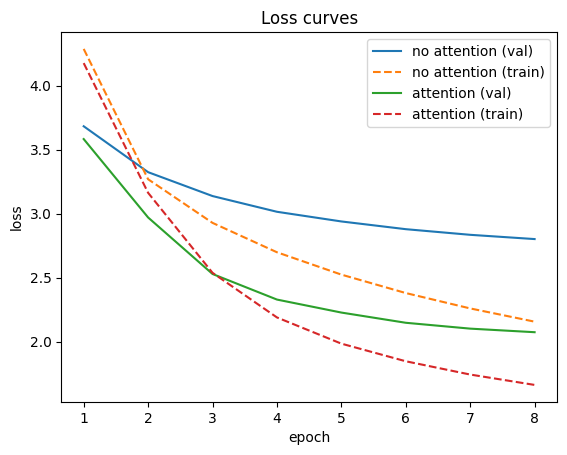

In [9]:
for hist, name in ((base_hist, "no attention"), (attn_hist, "attention")):
    if hist[1]:
        plt.plot(range(1, len(hist[1]) + 1), hist[1], label=f"{name} (val)")
        plt.plot(range(1, len(hist[0]) + 1), hist[0], "--", label=f"{name} (train)")
plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend(); plt.title("Loss curves")
plt.show()

## Evaluation: no attention vs attention (greedy decoding)
BLEU on the test split (tokenizer-based BLEU, same tokenizer for hypotheses and references). Test sentences are not capped at 30 tokens,
so the effect on long sentences is visible.

test sentences: 8466


                  model  BLEU (all)  len 1-10  len 11-20  len 21-30  len 31-60  time (s)
   No attention (Exp 1)       11.73     22.04      14.86      10.21       7.51         4
Luong attention (Exp 2)       26.04     33.76      29.29      26.25      21.13         4


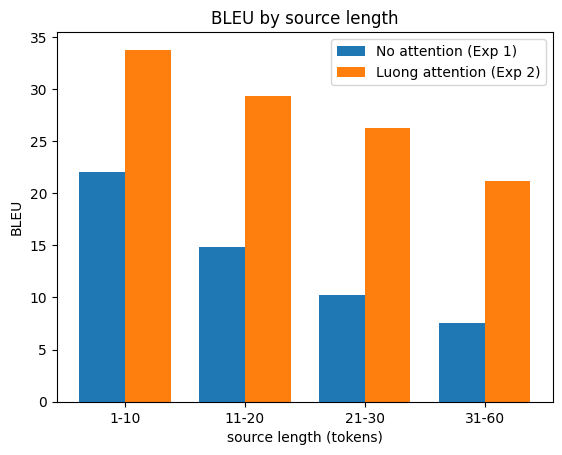

In [12]:
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
smooth = SmoothingFunction().method1

EVAL_MAX_SRC = 60    
TEST_LIMIT   = None    

test_e = test[(test["en_tok"].str.len() >= 1) & (test["en_tok"].str.len() <= EVAL_MAX_SRC)].reset_index(drop=True)
if TEST_LIMIT:
    test_e = test_e.sample(min(TEST_LIMIT, len(test_e)), random_state=SEED).reset_index(drop=True)
test_e["src_len"] = test_e["en_tok"].str.len()
labels = ["1-10", "11-20", "21-30", f"31-{EVAL_MAX_SRC}"]
test_e["bucket"] = pd.cut(test_e["src_len"], bins=[0, 10, 20, 30, EVAL_MAX_SRC], labels=labels)
print("test sentences:", len(test_e))


def bleu_score(refs_tok, hyps):
    if len(hyps) == 0:
        return float("nan")
    return corpus_bleu([[r] for r in refs_tok], hyps, smoothing_function=smooth) * 100


def translate_with(m, token_lists, bs=256, max_len=80, decode_fn=None):
    # batched decoding for any model with .greedy_decode (or pass decode_fn(src) -> ids)
    m.eval()
    enc = [encode_ids(t, en_vocab, max_len=EVAL_MAX_SRC) for t in token_lists]
    order = np.argsort([len(e) for e in enc])
    results = [None] * len(enc)
    for i in tqdm(range(0, len(order), bs), leave=False):
        idx = order[i:i + bs]
        src = pad_sequence([torch.tensor(enc[j]) for j in idx], padding_value=PAD).to(device)
        out = decode_fn(src) if decode_fn else m.greedy_decode(src, max_len=max_len)
        for k, j in enumerate(idx):
            words = []
            for t in out[k].tolist():
                if t == EOS:
                    break
                words.append(fr_id_to_word[t])
            results[j] = words
    return results


ref_toks = list(test_e["fr_tok"])
src_toks = list(test_e["en_tok"])
bucket_arr = test_e["bucket"].astype(str).values

systems = {"No attention (Exp 1)": baseline, "Luong attention (Exp 2)": attn_model}
greedy_out, rows = {}, []
for name, m in systems.items():
    t0 = time.time()
    h = translate_with(m, src_toks)
    greedy_out[name] = h
    row = {"model": name, "BLEU (all)": round(bleu_score(ref_toks, h), 2)}
    for lab in labels:
        idx = np.where(bucket_arr == lab)[0]
        row[f"len {lab}"] = round(bleu_score([ref_toks[i] for i in idx], [h[i] for i in idx]), 2)
    row["time (s)"] = round(time.time() - t0)
    rows.append(row)

cmp_table = pd.DataFrame(rows)
print(cmp_table.to_string(index=False))

x = np.arange(len(labels)); w = 0.38
for k, name in enumerate(systems):
    plt.bar(x + (k - 0.5) * w, [cmp_table.loc[k, f"len {lab}"] for lab in labels], w, label=name)
plt.xticks(x, labels); plt.xlabel("source length (tokens)"); plt.ylabel("BLEU")
plt.title("BLEU by source length"); plt.legend(); plt.show()

In [13]:
unk_src = sum(w not in en_vocab for t in src_toks for w in t) / sum(len(t) for t in src_toks)
unk_ref = sum(w not in fr_vocab for t in ref_toks for w in t) / sum(len(t) for t in ref_toks)
print(f"source tokens -> <UNK>: {unk_src:.2%} | reference tokens not in FR vocab: {unk_ref:.2%}")
for name, h in greedy_out.items():
    print(f"{name}: <UNK> in output = {sum(w == '<UNK>' for s in h for w in s)/max(sum(len(s) for s in h),1):.2%}, "
          f"hyp/ref length = {sum(len(s) for s in h)/sum(len(r) for r in ref_toks):.2f}")

source tokens -> <UNK>: 2.41% | reference tokens not in FR vocab: 2.76%
No attention (Exp 1): <UNK> in output = 5.29%, hyp/ref length = 0.94
Luong attention (Exp 2): <UNK> in output = 4.40%, hyp/ref length = 0.92


## Decoding strategies (attention model)
- **Greedy:** take the single most likely word at every step. Fast, but an early mistake can't be undone.
- **Beam search (k):** keep the `k` best partial translations at each step and return the best finished one.
  Scores are divided by length of alpha
- **Top-k sampling:** sample from the `k` most likely words.

Beam search runs one sentence at a time, so the comparison uses a random subset of the test set

In [16]:
@torch.no_grad()
def beam_search(m, src_ids, beam_size=5, max_len=80, alpha=1.0):
    # one sentence; src_ids includes <SOS> and <EOS>; returns French token ids (without <EOS>)
    m.eval()
    src = torch.tensor(src_ids, device=device).unsqueeze(1)           # (S, 1)
    enc_out, hidden, cell, mask = m.encoder(src)                       # (1, S, H)
    K = beam_size
    V = m.decoder.output_dim
    seqs = torch.full((1, 1), SOS, dtype=torch.long, device=device)    # (n_beams, len)
    scores = torch.zeros(1, device=device)
    finished = []                                                      # (normalised score, token ids)

    for step in range(max_len):
        n = seqs.shape[0]
        logits, hidden, cell, _ = m.decoder.step(seqs[:, -1], hidden, cell,
                                                 enc_out.repeat(n, 1, 1), mask.repeat(n, 1))
        logp = torch.log_softmax(logits.float(), dim=-1)               # (n, V)
        cand = (scores.unsqueeze(1) + logp).view(-1)
        top_scores, top_idx = cand.topk(min(2 * K, cand.numel()))
        beam_idx = (top_idx // V).tolist()
        tok_idx = (top_idx % V).tolist()

        keep_beam, keep_tok, keep_score = [], [], []
        for sc, bi, ti in zip(top_scores.tolist(), beam_idx, tok_idx):
            if ti == EOS:
                seq = seqs[bi, 1:].tolist()
                finished.append((sc / ((len(seq) + 1) ** alpha), seq))
            else:
                keep_beam.append(bi); keep_tok.append(ti); keep_score.append(sc)
            if len(keep_beam) == K:
                break

        if not keep_beam:
            break
        if len(finished) >= K:
            best_fin = max(f[0] for f in finished)
            best_alive = max(keep_score) / ((step + 1) ** alpha)
            if best_alive <= best_fin:
                break

        sel = torch.tensor(keep_beam, device=device)
        seqs = torch.cat([seqs[sel], torch.tensor(keep_tok, device=device).unsqueeze(1)], dim=1)
        scores = torch.tensor(keep_score, device=device)
        hidden, cell = hidden[:, sel], cell[:, sel]

    if not finished:                            
        for sc, seq in zip(scores.tolist(), seqs[:, 1:].tolist()):
            finished.append((sc / (max(len(seq), 1) ** alpha), seq))
    return max(finished, key=lambda f: f[0])[1]


def translate_beam(m, token_lists, beam_size=5, alpha=1.0, max_len=80):
    out = []
    for toks in tqdm(token_lists, leave=False):
        ids = beam_search(m, encode_ids(toks, en_vocab, EVAL_MAX_SRC), beam_size, max_len, alpha)
        out.append([fr_id_to_word[i] for i in ids])
    return out

In [17]:
N_STRAT = 500       
rng = np.random.RandomState(SEED)
sub = rng.choice(len(test_e), min(N_STRAT, len(test_e)), replace=False)
sub_src = [src_toks[i] for i in sub]
sub_ref = [ref_toks[i] for i in sub]

torch.manual_seed(SEED)
strategies = [
    ("Greedy", lambda toks: translate_with(attn_model, toks)),
    ("Beam k=3", lambda toks: translate_beam(attn_model, toks, 3, 1.0)),
    ("Beam k=5", lambda toks: translate_beam(attn_model, toks, 5, 1.0)),
    ("Beam k=5, no length norm", lambda toks: translate_beam(attn_model, toks, 5, 0.0)),
    ("Beam k=10", lambda toks: translate_beam(attn_model, toks, 10, 1.0)),
    ("Top-k sampling (k=10, T=0.8)", lambda toks: translate_with(
        attn_model, toks, decode_fn=lambda src: attn_model.sample_decode(src, 80, 10, 0.8))),
]

strat_out, rows = {}, []
for name, fn in strategies:
    t0 = time.time()
    h = fn(sub_src)
    dt = time.time() - t0
    strat_out[name] = h
    ratio = sum(len(x) for x in h) / max(sum(len(r) for r in sub_ref), 1)
    rows.append({"strategy": name, "BLEU": round(bleu_score(sub_ref, h), 2),
                 "hyp/ref length": round(ratio, 2), "time (s)": round(dt, 1)})
    print(rows[-1])

strat_table = pd.DataFrame(rows)
print()
print(strat_table.to_string(index=False))

{'strategy': 'Greedy', 'BLEU': 26.9, 'hyp/ref length': 0.91, 'time (s)': 0.7}


{'strategy': 'Beam k=3', 'BLEU': 29.6, 'hyp/ref length': 0.92, 'time (s)': 18.1}


{'strategy': 'Beam k=5', 'BLEU': 30.03, 'hyp/ref length': 0.92, 'time (s)': 21.0}


{'strategy': 'Beam k=5, no length norm', 'BLEU': 29.53, 'hyp/ref length': 0.89, 'time (s)': 21.1}


{'strategy': 'Beam k=10', 'BLEU': 30.46, 'hyp/ref length': 0.92, 'time (s)': 22.4}


{'strategy': 'Top-k sampling (k=10, T=0.8)', 'BLEU': 20.64, 'hyp/ref length': 0.93, 'time (s)': 0.6}

                    strategy  BLEU  hyp/ref length  time (s)
                      Greedy 26.90            0.91       0.7
                    Beam k=3 29.60            0.92      18.1
                    Beam k=5 30.03            0.92      21.0
    Beam k=5, no length norm 29.53            0.89      21.1
                   Beam k=10 30.46            0.92      22.4
Top-k sampling (k=10, T=0.8) 20.64            0.93       0.6
